In [1]:
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

df = pd.read_csv("../data/dataset_selection_sans_leger.csv")
print("Aperçu du dataset :")
print(df.head())
print("\nInformations générales :")
print(df.info())

Aperçu du dataset :
                                                path     label
0  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
1  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
2  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome
3  /home/mathis/Memoire/data/glaucome/ORIGA/ORIGA...  glaucome
4  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6208 entries, 0 to 6207
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   path    6208 non-null   object
 1   label   6208 non-null   object
dtypes: object(2)
memory usage: 97.1+ KB
None


In [2]:
print(f"Nombre total d'images : {len(df)}")
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre total d'images : 6208
Nombre de colonnes : 2


In [3]:
class_counts = df['label'].value_counts()
print("\nRépartition des labels :")
print(class_counts)
class_percent = df['label'].value_counts(normalize=True) * 100
print("\nPourcentage par label :")
print(class_percent.round(2))


Répartition des labels :
label
glaucome    1552
mda         1552
diabete     1552
normaux     1552
Name: count, dtype: int64

Pourcentage par label :
label
glaucome    25.0
mda         25.0
diabete     25.0
normaux     25.0
Name: proportion, dtype: float64


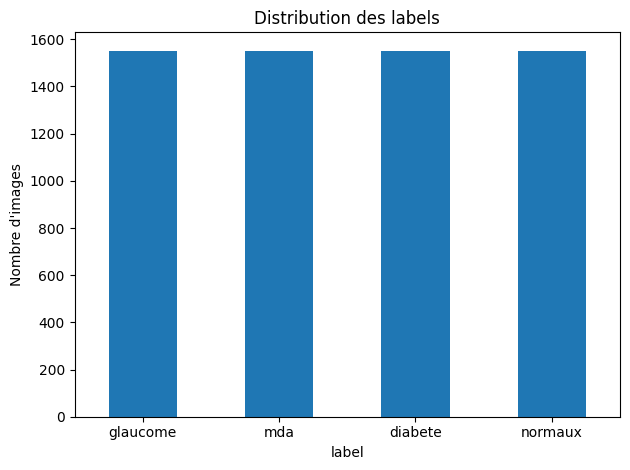

In [4]:
import matplotlib.pyplot as plt

class_counts.plot(kind='bar')
plt.title("Distribution des labels")
plt.xlabel("label")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
for classe in df['label'].unique():
    print(f"\nExemples pour la classe '{classe}' :")
    print(df[df['label'] == classe]['path'].head(3).tolist())


Exemples pour la classe 'glaucome' :
['/home/mathis/Memoire/data/glaucome/LAG/LAG/Training/glaucoma/1308.jpg', '/home/mathis/Memoire/data/glaucome/LAG/LAG/Training/glaucoma/1456.jpg', '/home/mathis/Memoire/data/glaucome/LAG/LAG/Testing/glaucoma/4275.jpg']

Exemples pour la classe 'mda' :
['/home/mathis/Memoire/data/mda/Fundus/Fundus/ARMD/161.png', '/home/mathis/Memoire/data/mda/Fundus/Fundus/ARMD/328.png', '/home/mathis/Memoire/data/mda/Fundus/Fundus/ARMD/235.png']

Exemples pour la classe 'diabete' :
['/home/mathis/Memoire/data/diabete/train.zip/train/25985_right.jpeg', '/home/mathis/Memoire/data/diabete/train.zip/train/38016_right.jpeg', '/home/mathis/Memoire/data/diabete/train.zip/train/20574_left.jpeg']

Exemples pour la classe 'normaux' :
['/home/mathis/Memoire/data/mda/ODIR-5K/ODIR-5K/Training Images/2457_right.jpg', '/home/mathis/Memoire/data/diabete/train.zip/train/30306_left.jpeg', '/home/mathis/Memoire/data/diabete/train.zip/train/3710_left.jpeg']


In [6]:
from sklearn.model_selection import train_test_split

df_train, df_temp = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)
df_test, df_val = train_test_split(
    df_temp,
    test_size=0.5,
    stratify=df_temp['label'],
    random_state=42
)

print("Tailles des splits :")
print(f"Train : {len(df_train)}")
print(f"Test  : {len(df_test)}")
print(f"Val   : {len(df_val)}")

Tailles des splits :
Train : 4966
Test  : 621
Val   : 621


In [7]:
def show_distribution(name, data):
    print(f"\n{name}")
    print(data['label'].value_counts(normalize=True).round(3))

show_distribution("Train", df_train)
show_distribution("Test", df_test)
show_distribution("Validation", df_val)


Train
label
glaucome    0.25
normaux     0.25
mda         0.25
diabete     0.25
Name: proportion, dtype: float64

Test
label
mda         0.251
glaucome    0.250
diabete     0.250
normaux     0.250
Name: proportion, dtype: float64

Validation
label
diabete     0.251
glaucome    0.250
normaux     0.250
mda         0.250
Name: proportion, dtype: float64


In [8]:
import numpy as np
from PIL import Image

IMG_SIZE = (256, 256)
BATCH_SIZE = 32
SEED = 42

torch.manual_seed(SEED)

classes = sorted(df["label"].unique().tolist())
label_to_id = {c: i for i, c in enumerate(classes)}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"Classes : {classes}")

Device : cuda
Classes : ['diabete', 'glaucome', 'mda', 'normaux']


In [9]:
def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    arr = np.array(img)
    gray = arr.mean(axis=2)
    mask = gray > thr
    if not mask.any():
        return img
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(arr.shape[0] - 1, y1 + pad)
    x1 = min(arr.shape[1] - 1, x1 + pad)
    return img.crop((x0, y0, x1 + 1, y1 + 1))

In [10]:
class MedicalDataset(Dataset):
    def __init__(self, df, label_to_id, transform=None):
        self.paths   = df["path"].astype(str).values
        self.labels  = df["label"].map(label_to_id).astype(int).values
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            img = crop_black_border_pil(img, thr=10, pad=10)
            if self.transform:
                img = self.transform(img)
            return img, self.labels[idx]
        except Exception:
            img = torch.zeros(3, *IMG_SIZE)
            return img, self.labels[idx]


train_transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomRotation(3),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),
    T.ToTensor(),
])

val_transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
])

train_loader = DataLoader(MedicalDataset(df_train, label_to_id, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(MedicalDataset(df_val,   label_to_id, val_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(MedicalDataset(df_test,  label_to_id, val_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [11]:
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(),
        nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(),
        nn.MaxPool2d(2),
    )


class GrosCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3,   64),
            conv_block(64,  128),
            conv_block(128, 256),
            conv_block(256, 512),
            conv_block(512, 512),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4), nn.Linear(512, 1024), nn.ReLU(),
            nn.Dropout(0.4), nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model     = GrosCNN(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

total_params = sum(p.numel() for p in model.parameters())
print(f"Nombre de paramètres : {total_params:,}")
print(model)

Nombre de paramètres : 10,463,044
GrosCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, pad

In [12]:
import copy

best_val_loss    = float("inf")
best_weights     = None
patience         = 7
patience_counter = 0
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

for epoch in range(50):
    # --- Entraînement ---
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += len(labels)
    train_loss = total_loss / total
    train_acc  = correct / total

    # --- Validation ---
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            val_loss_sum += loss.item() * len(labels)
            val_correct  += (outputs.argmax(1) == labels).sum().item()
            val_total    += len(labels)
    val_loss = val_loss_sum / val_total
    val_acc  = val_correct  / val_total

    scheduler.step(val_loss)

    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)

    print(f"Epoch {epoch+1:2d}/50  loss: {train_loss:.4f}  acc: {train_acc:.4f}"
          f"  |  val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}"
          f"  |  lr: {optimizer.param_groups[0]['lr']:.2e}")

    # --- Early stopping ---
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_weights     = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping — epoch {epoch+1}")
            break

model.load_state_dict(best_weights)

Epoch  1/50  loss: 0.9920  acc: 0.5546  |  val_loss: 1.0067  val_acc: 0.5974  |  lr: 1.00e-03
Epoch  2/50  loss: 0.9048  acc: 0.6061  |  val_loss: 1.4038  val_acc: 0.4525  |  lr: 1.00e-03
Epoch  3/50  loss: 0.8743  acc: 0.6224  |  val_loss: 0.9041  val_acc: 0.6055  |  lr: 1.00e-03
Epoch  4/50  loss: 0.8597  acc: 0.6232  |  val_loss: 1.6711  val_acc: 0.4750  |  lr: 1.00e-03
Epoch  5/50  loss: 0.8563  acc: 0.6303  |  val_loss: 0.8549  val_acc: 0.6135  |  lr: 1.00e-03
Epoch  6/50  loss: 0.8556  acc: 0.6248  |  val_loss: 0.8099  val_acc: 0.6490  |  lr: 1.00e-03
Epoch  7/50  loss: 0.8523  acc: 0.6297  |  val_loss: 1.0498  val_acc: 0.5169  |  lr: 1.00e-03
Epoch  8/50  loss: 0.8406  acc: 0.6343  |  val_loss: 0.7985  val_acc: 0.6602  |  lr: 1.00e-03
Epoch  9/50  loss: 0.8154  acc: 0.6422  |  val_loss: 0.8108  val_acc: 0.6779  |  lr: 1.00e-03
Epoch 10/50  loss: 0.8298  acc: 0.6410  |  val_loss: 1.5114  val_acc: 0.4734  |  lr: 1.00e-03
Epoch 11/50  loss: 0.8006  acc: 0.6476  |  val_loss: 0.8063 

<All keys matched successfully>


=== Scores globaux ===
Accuracy            : 0.7069
Balanced accuracy   : 0.7065
Precision (macro)   : 0.7039
Recall    (macro)   : 0.7065
F1        (macro)   : 0.6566
Precision (weighted): 0.7038
Recall    (weighted): 0.7069
F1        (weighted): 0.6568

=== Rapport par classe ===
              precision    recall  f1-score   support

     diabete       0.70      0.78      0.74       155
    glaucome       0.79      0.93      0.85       155
         mda       0.65      0.96      0.78       156
     normaux       0.68      0.16      0.26       155

    accuracy                           0.71       621
   macro avg       0.70      0.71      0.66       621
weighted avg       0.70      0.71      0.66       621



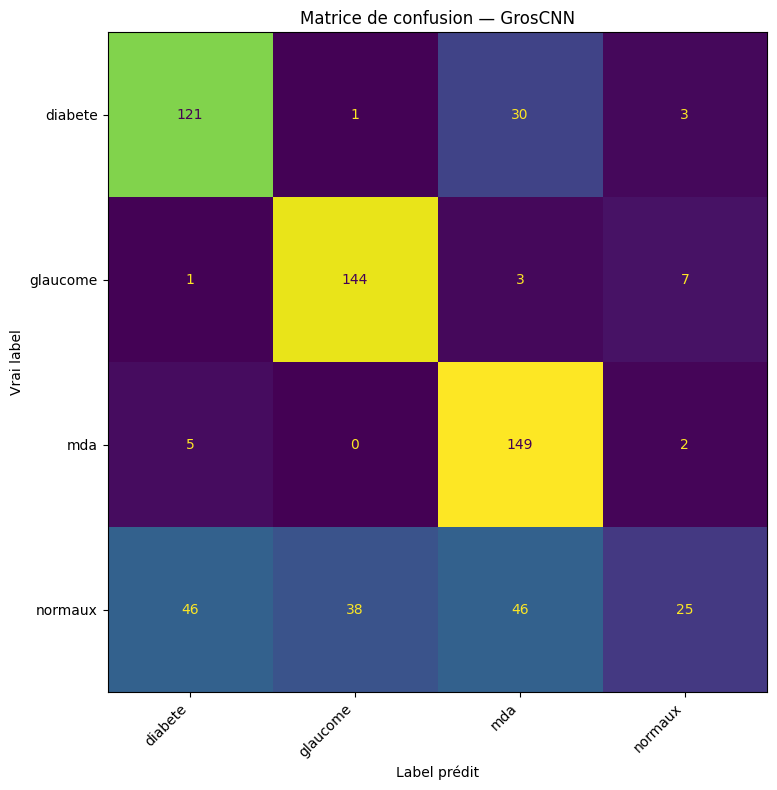

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    f1_score, balanced_accuracy_score, classification_report
)

model.eval()
y_true_list, y_pred_list = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        y_pred_list.extend(preds)
        y_true_list.extend(labels.numpy())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

print("\n=== Scores globaux ===")
print(f"Accuracy            : {accuracy_score(y_true, y_pred):.4f}")
print(f"Balanced accuracy   : {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"Precision (macro)   : {precision_score(y_true, y_pred, average='macro',    zero_division=0):.4f}")
print(f"Recall    (macro)   : {recall_score(   y_true, y_pred, average='macro',    zero_division=0):.4f}")
print(f"F1        (macro)   : {f1_score(       y_true, y_pred, average='macro',    zero_division=0):.4f}")
print(f"Precision (weighted): {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall    (weighted): {recall_score(   y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1        (weighted): {f1_score(       y_true, y_pred, average='weighted', zero_division=0):.4f}")
print("\n=== Rapport par classe ===")
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

cm   = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(
    ax=ax, values_format="d", cmap=None, colorbar=False)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Label prédit")
plt.ylabel("Vrai label")
plt.title("Matrice de confusion — GrosCNN")
plt.tight_layout()
plt.show()